<a href="https://colab.research.google.com/github/Suhanii054/DEEP-LEARNING/blob/main/LAB-3/CNN-Loss-Optimizer_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# Transforms
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# MNIST
mnist_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=mnist_transform
)
mnist_test = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=mnist_transform
)

# CIFAR-10
cifar_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=cifar_transform
)
cifar_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=cifar_transform
)

mnist_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=64)

cifar_loader = DataLoader(cifar_train, batch_size=64, shuffle=True)
cifar_test_loader = DataLoader(cifar_test, batch_size=64)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]
100%|██████████| 170M/170M [00:04<00:00, 34.4MB/s]


In [ ]:
class VGGNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [ ]:
def train_model(model, loader, optimizer, criterion, epochs):
    model.train()
    for epoch in range(epochs):
        correct = 0
        total = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            labels_onehot = torch.zeros(labels.size(0), 10).to(device)
            labels_onehot.scatter_(1, labels.unsqueeze(1), 1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_onehot)
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f"Epoch {epoch+1}, Train Acc: {100*correct/total:.2f}%")


In [ ]:
vgg = VGGNetSmall().to(device)
criterion_bce = nn.BCELoss()
optimizer = optim.Adam(vgg.parameters(), lr=0.001)

train_model(vgg, mnist_loader, optimizer, criterion_bce, epochs=10)


Epoch 1, Train Acc: 92.50%
Epoch 2, Train Acc: 98.44%
Epoch 3, Train Acc: 98.92%
Epoch 4, Train Acc: 99.20%
Epoch 5, Train Acc: 99.36%
Epoch 6, Train Acc: 99.54%
Epoch 7, Train Acc: 99.66%
Epoch 8, Train Acc: 99.75%
Epoch 9, Train Acc: 99.78%
Epoch 10, Train Acc: 99.79%


In [ ]:
def test_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")


In [ ]:
test_model(vgg, mnist_test_loader)


Test Accuracy: 99.22%


### VGGNet + Adam + BCE (MNIST)

- **Training Accuracy (final epoch):** 99.79%
- **Testing Accuracy:** 99.22%


In [ ]:
class AlexNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss


In [ ]:
alexnet = AlexNetSmall().to(device)
criterion_focal = FocalLoss()
optimizer = optim.SGD(alexnet.parameters(), lr=0.01, momentum=0.9)

alexnet.train()
for epoch in range(20):
    correct = 0
    total = 0
    for images, labels in cifar_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = alexnet(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer.step()

        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}, Train Acc: {100*correct/total:.2f}%")


Epoch 1, Train Acc: 47.84%
Epoch 2, Train Acc: 64.62%
Epoch 3, Train Acc: 71.69%
Epoch 4, Train Acc: 76.49%
Epoch 5, Train Acc: 81.24%
Epoch 6, Train Acc: 85.34%
Epoch 7, Train Acc: 89.14%
Epoch 8, Train Acc: 91.77%
Epoch 9, Train Acc: 93.91%
Epoch 10, Train Acc: 95.29%
Epoch 11, Train Acc: 96.35%
Epoch 12, Train Acc: 97.10%
Epoch 13, Train Acc: 97.50%
Epoch 14, Train Acc: 97.84%
Epoch 15, Train Acc: 98.19%
Epoch 16, Train Acc: 98.39%
Epoch 17, Train Acc: 98.63%
Epoch 18, Train Acc: 98.76%
Epoch 19, Train Acc: 98.92%
Epoch 20, Train Acc: 99.06%


In [ ]:
def test_model_ce(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")


In [ ]:
test_model_ce(alexnet, cifar_test_loader)


Test Accuracy: 75.54%


### AlexNet + SGD + Focal Loss (CIFAR-10)

- **Training Accuracy (Epoch 20):** 99.06%
- **Testing Accuracy:** 75.54%


In [ ]:
class ArcFaceLoss(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.5):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        cosine = nn.functional.linear(
            nn.functional.normalize(embeddings),
            nn.functional.normalize(self.weight)
        )
        phi = cosine - self.m
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1,1), 1)
        logits = self.s * (one_hot * phi + (1.0 - one_hot) * cosine)
        return nn.CrossEntropyLoss()(logits, labels)


In [ ]:
class SimpleResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*16*16, 128)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [ ]:
resnet = SimpleResNet().to(device)
arcface = ArcFaceLoss(128, 10).to(device)
optimizer = optim.Adam(resnet.parameters(), lr=0.001)

resnet.train()
for epoch in range(15):
    correct = 0
    total = 0
    for images, labels in cifar_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        embeddings = resnet(images)
        loss = arcface(embeddings, labels)
        loss.backward()
        optimizer.step()

        total += labels.size(0)

    print(f"Epoch {epoch+1} completed")


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed


In [ ]:
def train_accuracy_arcface(model, arcface, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            embeddings = model(images)

            cosine = nn.functional.linear(
                nn.functional.normalize(embeddings),
                nn.functional.normalize(arcface.weight)
            )

            predicted = cosine.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Training Accuracy: {100 * correct / total:.2f}%")


In [ ]:
train_accuracy_arcface(resnet, arcface, cifar_loader)


Training Accuracy: 86.54%


In [ ]:
def test_accuracy_arcface(model, arcface, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            embeddings = model(images)

            cosine = nn.functional.linear(
                nn.functional.normalize(embeddings),
                nn.functional.normalize(arcface.weight)
            )

            predicted = cosine.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")


In [ ]:
test_accuracy_arcface(resnet, arcface, cifar_test_loader)


Test Accuracy: 64.61%


### ResNet + Adam + ArcFace (CIFAR-10)

- **Training Accuracy:** 86.54%
- **Testing Accuracy:** 64.61%


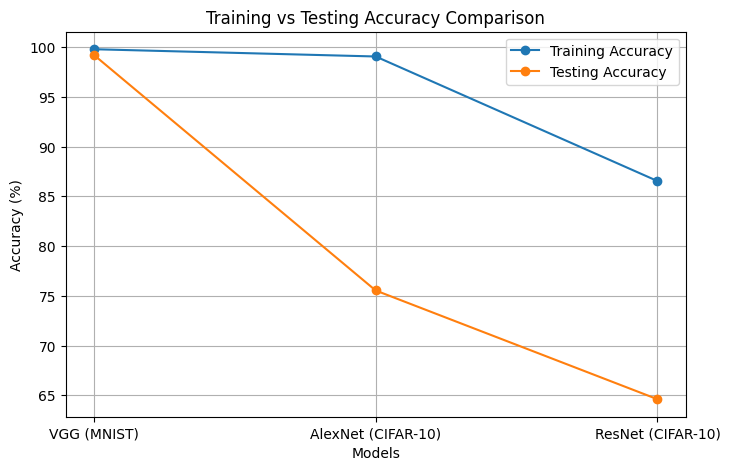

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = ["VGG (MNIST)", "AlexNet (CIFAR-10)", "ResNet (CIFAR-10)"]

# Accuracies (from your results)
train_acc = [99.79, 99.06, 86.54]
test_acc = [99.22, 75.54, 64.61]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(models, train_acc, marker='o', label="Training Accuracy")
plt.plot(models, test_acc, marker='o', label="Testing Accuracy")

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()


### **TASK 3**


To plot the Decision Boundaries or use t-SNE to visualize how different loss functions (like BCE vs. ArcFace) cluster the features of CIFAR-10.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [ ]:
def extract_features(model, loader, max_samples=2000):
    model.eval()
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embeddings = model(images)

            features.append(embeddings.cpu().numpy())
            labels_list.append(labels.numpy())

            if len(np.concatenate(features)) >= max_samples:
                break

    return np.concatenate(features)[:max_samples], np.concatenate(labels_list)[:max_samples]


In [ ]:
alexnet.eval()
alex_features, alex_labels = extract_features(alexnet, cifar_test_loader)


In [ ]:
resnet.eval()
resnet_features, resnet_labels = extract_features(resnet, cifar_test_loader)


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca'
)

alex_tsne = tsne.fit_transform(alex_features)
resnet_tsne = tsne.fit_transform(resnet_features)


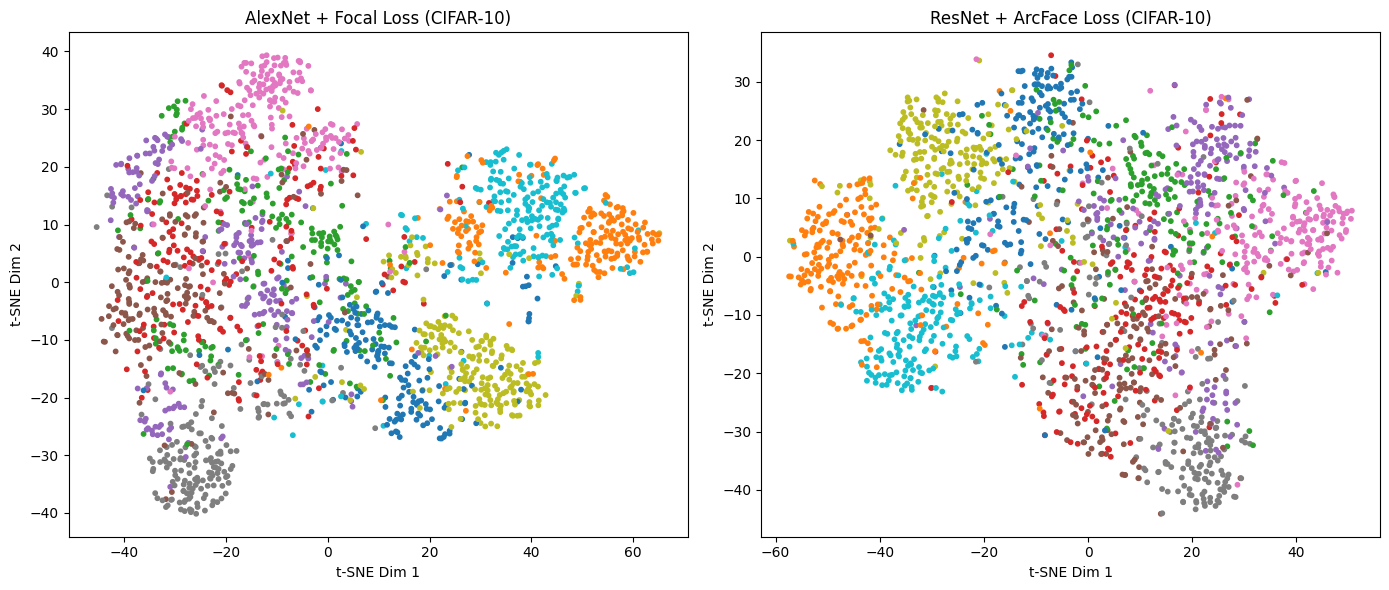

In [ ]:
plt.figure(figsize=(14, 6))

# AlexNet + Focal Loss
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(
    alex_tsne[:, 0],
    alex_tsne[:, 1],
    c=alex_labels,
    cmap='tab10',
    s=10
)
plt.title("AlexNet + Focal Loss (CIFAR-10)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

# ResNet + ArcFace
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(
    resnet_tsne[:, 0],
    resnet_tsne[:, 1],
    c=resnet_labels,
    cmap='tab10',
    s=10
)
plt.title("ResNet + ArcFace Loss (CIFAR-10)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

plt.tight_layout()
plt.show()
